# Chapter 2 - Data and Sampling Distributions

## Chapter summary
Data scientists usually work with a **sample** drawn from a larger **population**. This chapter explains how sampling affects what we can conclude:

1. **Random sampling and sample bias** - random vs. stratified sampling, selection bias, data snooping, the *regression to the mean* effect.
2. **Sampling distribution of a statistic** - the spread of a statistic (e.g. the mean) across many samples; the **Central Limit Theorem** and the **standard error**.
3. **The bootstrap** - estimating the sampling distribution by resampling the observed data *with replacement*.
4. **Confidence intervals** - a range expressing the uncertainty of an estimate.
5. **Normal distribution, QQ-plots, long-tailed distributions**.
6. **Student's t, binomial, chi-square, F, Poisson, exponential and Weibull distributions**.

In [23]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from pathlib import Path
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/"

def get_data(name):
    """Download a dataset of the book (once) into ./data and return its path."""
    path = Path("data") / name
    path.parent.mkdir(exist_ok=True)
    if not path.exists():
        urllib.request.urlretrieve(DATA_URL + name, path)
    return path

sns.set_style("whitegrid")
rng = np.random.default_rng(1)

## 1. Sampling distribution of a statistic

**Theory.**
* A *sample statistic* (mean, median, ...) computed on different samples gives different values. The distribution of those values is the **sampling distribution**.
* **Central Limit Theorem (CLT)**: even if the data are not normal, the sampling distribution of the *mean* is approximately normal when the sample size is large enough.
* **Standard error (SE)** is the standard deviation of the sampling distribution: $SE = \frac{s}{\sqrt{n}}$. Quadrupling the sample size halves the SE (the "square-root-of-n rule").
* Don't confuse the standard *deviation* (spread of individual data) with the standard *error* (spread of the statistic).

Data: annual incomes of Lending Club loan applicants (a skewed distribution).

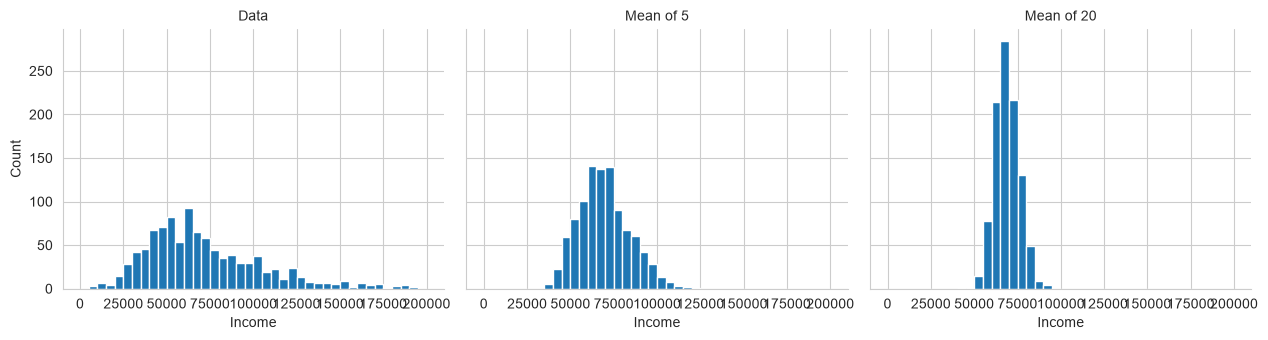

In [24]:
loans_income = pd.read_csv(get_data("loans_income.csv")).squeeze("columns")

sample_data = pd.DataFrame({
    "income": loans_income.sample(1000, random_state=1),
    "type": "Data",
})
sample_mean_05 = pd.DataFrame({
    "income": [loans_income.sample(5, random_state=i).mean() for i in range(1000)],
    "type": "Mean of 5",
})
sample_mean_20 = pd.DataFrame({
    "income": [loans_income.sample(20, random_state=i).mean() for i in range(1000)],
    "type": "Mean of 20",
})
results = pd.concat([sample_data, sample_mean_05, sample_mean_20])

g = sns.FacetGrid(results, col="type", col_wrap=3, height=3.5, aspect=1.2)
g.map(plt.hist, "income", range=[0, 200000], bins=40)
g.set_axis_labels("Income", "Count")
g.set_titles("{col_name}")
plt.show()

The raw data are skewed, but the distribution of means becomes narrower and more bell-shaped as the sample size grows - the CLT in action.

## 2. The Bootstrap

**Theory.** The bootstrap estimates the sampling distribution **without distributional assumptions**:

1. Draw a sample value, record it, and put it back (*sampling with replacement*).
2. Repeat $n$ times to create one *bootstrap resample* of the same size as the data.
3. Compute the statistic on that resample.
4. Repeat $R$ times (e.g. 1000) and examine the distribution of the statistic.

The spread of the bootstrap statistics estimates the standard error, and their percentiles give confidence intervals. Bootstrapping is *not* a way to compensate for a small sample - it tells us how the statistic would vary, not new information about the population.

In [25]:
results = []
for _ in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)

print("Bootstrap statistics:")
print(f"  original median: {loans_income.median():.1f}")
print(f"  bias           : {results.mean() - loans_income.median():.2f}")
print(f"  std. error     : {results.std():.2f}")

Bootstrap statistics:
  original median: 62000.0
  bias           : -81.04
  std. error     : 230.43


## 3. Confidence intervals

**Theory.** A **x% confidence interval** is a range built so that, in repeated sampling, x% of such intervals would contain the true value. Practically, it conveys the *uncertainty* around a sample estimate. Bootstrap recipe:

1. Draw a large number of bootstrap resamples and compute the statistic for each.
2. Trim $[(100-x)/2]\%$ off each tail. The cut-off points are the CI endpoints.

Higher confidence (99% vs 90%) gives a wider interval; larger samples give narrower ones.

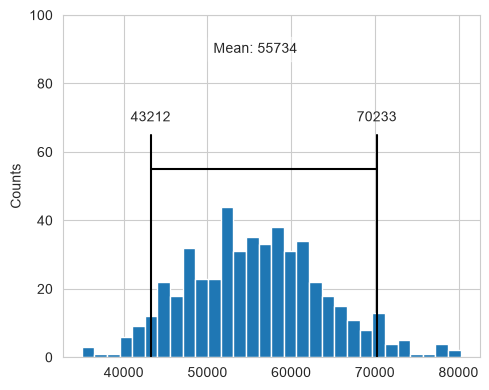

90% bootstrap confidence interval: [43212.45, 70233.43999999999]


In [26]:
np.random.seed(seed=3)
sample20 = loans_income.sample(20)
sample_mean = sample20.mean()

results = [resample(sample20).mean() for _ in range(500)]
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(5, 4))
ax.plot(confidence_interval, [55, 55], color="black")
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color="black")
    ax.text(x, 70, f"{x:.0f}", horizontalalignment="center", verticalalignment="center")
ax.text(sample_mean, 90, f"Mean: {sample_mean:.0f}", bbox=dict(facecolor="white", edgecolor="white", alpha=0.5),
        horizontalalignment="center", verticalalignment="center")
ax.set_ylim(0, 100); ax.set_ylabel("Counts")
plt.tight_layout(); plt.show()
print("90% bootstrap confidence interval:", confidence_interval)

## 4. Normal distribution and QQ-plots

**Theory.** The normal (Gaussian) distribution is bell-shaped; 68% of values lie within 1 SD of the mean, 95% within 2 SD and 99.7% within 3 SD. A **z-score** $z=\frac{x-\mu}{\sigma}$ expresses how many SDs a value is from the mean ("standardization"; with normalized data, the *standard normal* has mean 0 and SD 1).

A **QQ-plot** plots sorted, standardized data against theoretical normal quantiles. Points falling on the diagonal line indicate the data are approximately normal. Contrary to its name, the normal distribution is *not* the norm for raw data - it is mostly useful for the distribution of *statistics* (via the CLT).

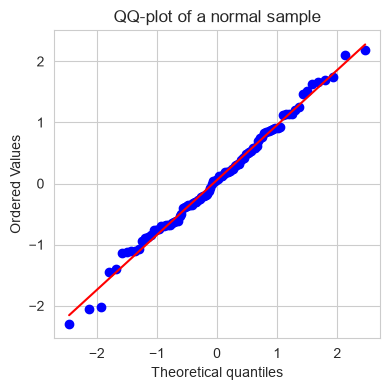

In [27]:
fig, ax = plt.subplots(figsize=(4, 4))
norm_sample = stats.norm.rvs(size=100, random_state=1)
stats.probplot(norm_sample, plot=ax)
ax.set_title("QQ-plot of a normal sample")
plt.tight_layout(); plt.show()

## 5. Long-tailed distributions

**Theory.** Real data are often **skewed** or have **fat tails** (more extreme values than the normal predicts - the QQ-plot curves away from the line at the ends). Ignoring this underestimates the probability of extreme events ("black swans"). Example: daily returns of Netflix stock.

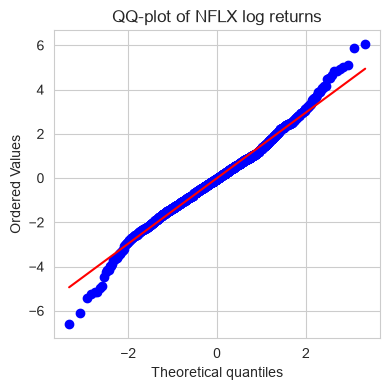

In [28]:
sp500_px = pd.read_csv(get_data("sp500_data.csv.gz"), index_col=0)
nflx = sp500_px["NFLX"]
nflx = np.diff(np.log(nflx[nflx > 0]))

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax)
ax.set_title("QQ-plot of NFLX log returns")
plt.tight_layout(); plt.show()

## 6. Student's t-distribution

**Theory.** The t-distribution is bell-shaped like the normal but with heavier tails. It is used for the sampling distribution of a mean when the population SD is unknown and estimated from a sample, $t=\frac{\bar{x}-\mu}{s/\sqrt{n}}$. It depends on the **degrees of freedom** ($n-1$); as it grows the t-distribution converges to the normal. It underlies t-tests and confidence intervals for means.

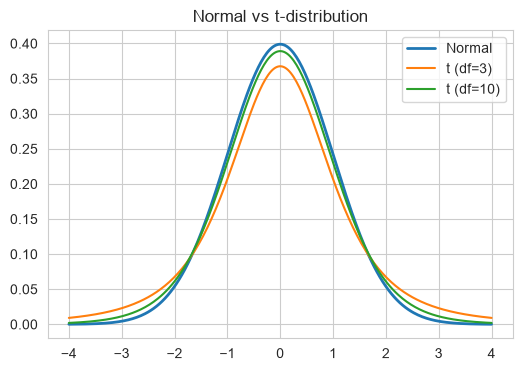

In [29]:
x = np.linspace(-4, 4, 300)
plt.figure(figsize=(6, 4))
plt.plot(x, stats.norm.pdf(x), label="Normal", lw=2)
for df in (3, 10):
    plt.plot(x, stats.t.pdf(x, df), label=f"t (df={df})")
plt.legend(); plt.title("Normal vs t-distribution"); plt.show()

## 7. Binomial distribution

**Theory.** The number of successes in $n$ independent trials, each with success probability $p$ (a *Bernoulli trial* yields 1/0):

$$ P(X=k)=\binom{n}{k}p^k(1-p)^{n-k},\quad E[X]=np,\quad \mathrm{Var}[X]=np(1-p). $$

Example: probability of 2 sales from 5 website visitors with a 0.1 click-through-like rate $p=0.1$ -> `stats.binom.pmf(2, n=5, p=0.1)`.

In [30]:
print("P(2 successes in 5 trials, p=0.1):", stats.binom.pmf(2, n=5, p=0.1))
print("P(<=2 successes in 5 trials)     :", stats.binom.cdf(2, n=5, p=0.1))

P(2 successes in 5 trials, p=0.1): 0.07289999999999992
P(<=2 successes in 5 trials)     : 0.99144


## 8. Chi-square distribution

**Theory.** The chi-square statistic measures how far observed counts deviate from expected counts under a null hypothesis (used in tests of independence / goodness-of-fit, Chapter 3). Its distribution depends on the degrees of freedom and is right-skewed.

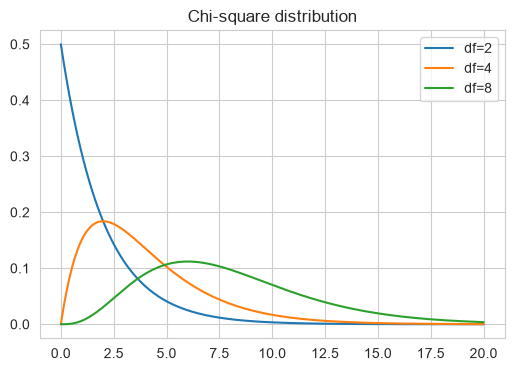

In [31]:
x = np.linspace(0, 20, 300)
plt.figure(figsize=(6, 4))
for df in (2, 4, 8):
    plt.plot(x, stats.chi2.pdf(x, df), label=f"df={df}")
plt.legend(); plt.title("Chi-square distribution"); plt.show()

## 9. F-distribution

**Theory.** The F-distribution is the ratio of two variances (scaled chi-squares) and is the reference distribution of the **F-statistic** in ANOVA and regression (Chapters 3 and 4). It has two degrees-of-freedom parameters (numerator, denominator).

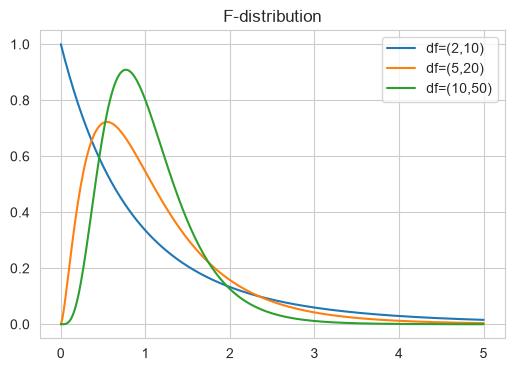

In [32]:
x = np.linspace(0, 5, 300)
plt.figure(figsize=(6, 4))
for dfn, dfd in ((2, 10), (5, 20), (10, 50)):
    plt.plot(x, stats.f.pdf(x, dfn, dfd), label=f"df=({dfn},{dfd})")
plt.legend(); plt.title("F-distribution"); plt.show()

## 10. Poisson and related distributions

**Theory.**
* **Poisson**: number of events in a fixed interval when events occur independently at an average rate $\lambda$; $E[X]=\mathrm{Var}[X]=\lambda$.
* **Exponential**: the *time between* Poisson events, with rate $\lambda$ (mean $1/\lambda$).
* **Weibull**: generalises the exponential to allow the event rate to change over time via a shape parameter $\beta$ (used in reliability / time-to-failure; $\beta>1$ means failure rate increases with time).

Poisson sample (lambda=2): [2 1 0 1 2 2 0 3 3 3 0 2 4 2 4]
Exponential sample (rate 0.2, mean 5): [2.7  6.37 0.   1.8  0.79]
Weibull sample (shape 1.5, scale 5000): [3314. 5876.   12. 2530. 1466.]


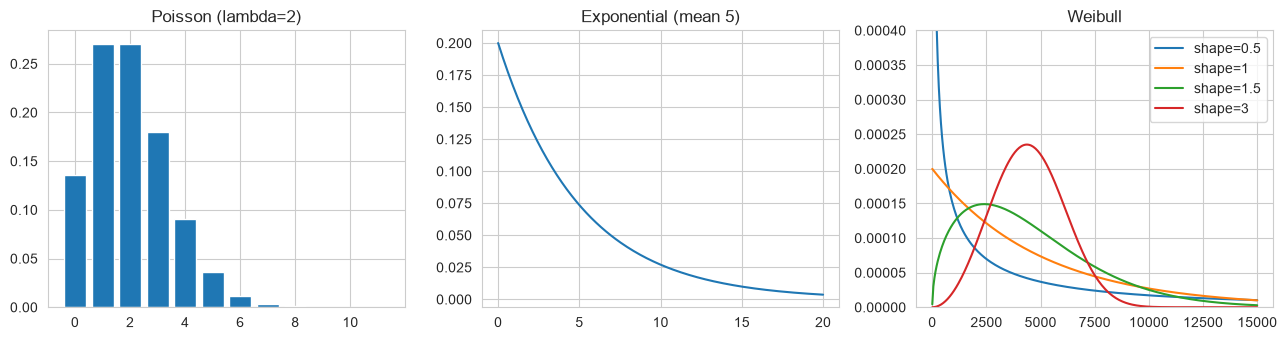

In [33]:
print("Poisson sample (lambda=2):", stats.poisson.rvs(2, size=15, random_state=1))
print("Exponential sample (rate 0.2, mean 5):", np.round(stats.expon.rvs(scale=5, size=5, random_state=1), 2))
print("Weibull sample (shape 1.5, scale 5000):", np.round(stats.weibull_min.rvs(1.5, scale=5000, size=5, random_state=1), 0))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
k = np.arange(0, 12)
axes[0].bar(k, stats.poisson.pmf(k, 2)); axes[0].set_title("Poisson (lambda=2)")
x = np.linspace(0, 20, 200)
axes[1].plot(x, stats.expon.pdf(x, scale=5)); axes[1].set_title("Exponential (mean 5)")
x = np.linspace(1, 15000, 300)   # start just above 0: the shape=0.5 density is infinite at x=0
for c in (0.5, 1, 1.5, 3):
    axes[2].plot(x, stats.weibull_min.pdf(x, c, scale=5000), label=f"shape={c}")
axes[2].set_ylim(0, 0.0004)   # shape=0.5 diverges at 0, so cap the y-axis to keep the other curves readable
axes[2].legend(); axes[2].set_title("Weibull")
plt.tight_layout(); plt.show()

## Key takeaways
* The **sampling distribution** of a statistic quantifies how much it varies from sample to sample; the **CLT** makes the mean approximately normal for large samples.
* The **bootstrap** gives standard errors and confidence intervals with no distributional assumptions.
* A **confidence interval** expresses uncertainty about an estimate; more data -> narrower interval.
* Check normality with a **QQ-plot**; real data are often long-tailed.
* Know the main distributions: t (means), binomial (counts of successes), chi-square (counts/independence), F (variance ratios), Poisson/exponential/Weibull (event counts and times).